In [1]:
!pip install gensim

# 1. Uploading data

In [2]:
from datasets import load_dataset, tqdm
import gensim.downloader as api

In [3]:
wv = api.load('glove-wiki-gigaword-100')

In [4]:
dataset = load_dataset("ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
from tqdm import tqdm

## 1.1 Data analysis

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from typing import List
from datasets import concatenate_datasets

In [7]:
print(f"Train size = {len(dataset['train'])}")
print(f"Test size = {len(dataset['test'])}")

Train size = 120000
Test size = 7600


In [8]:
# Class balance analysisi

train_counts = Counter(dataset['train']['label'])
test_counts = Counter(dataset['test']['label'])

train_total = len(dataset['train']['label'])
test_total = len(dataset['test']['label'])

print("\nTrain:")
for class_label in sorted(train_counts.keys()):
    count = train_counts[class_label]
    percentage = (count / train_total) * 100
    print(f"  Class {class_label}: {count:6d} samples ({percentage:5.2f}%)")

print(f"\nTotal: {train_total} samples")

print("\nTest:")
for class_label in sorted(test_counts.keys()):
    count = test_counts[class_label]
    percentage = (count / test_total) * 100
    print(f"  Class {class_label}: {count:6d} samples ({percentage:5.2f}%)")

print(f"\nTotal: {test_total} samples")


Train:
  Class 0:  30000 samples (25.00%)
  Class 1:  30000 samples (25.00%)
  Class 2:  30000 samples (25.00%)
  Class 3:  30000 samples (25.00%)

Total: 120000 samples

Test:
  Class 0:   1900 samples (25.00%)
  Class 1:   1900 samples (25.00%)
  Class 2:   1900 samples (25.00%)
  Class 3:   1900 samples (25.00%)

Total: 7600 samples


In [8]:
# Tokenizer

def tokenize(text: str) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)

    return [t.lower() for t in tokens]

In [10]:
# Check OOV Rate

def analyze_vocabulary(data_subset, model):
    total_tokens = 0
    oov_tokens = 0
    oov_words = Counter()

    for item in tqdm(data_subset):
        tokens = tokenize(item['text'])
        for token in tokens:
            total_tokens += 1
            if token not in model:
                oov_tokens += 1
                oov_words[token] += 1

    oov_rate = (oov_tokens / total_tokens) * 100

    return total_tokens, oov_tokens, oov_rate, oov_words

total, oov_count, rate, common_oov = analyze_vocabulary(concatenate_datasets([dataset['train'], dataset['test']]), wv)

print("Analisis vocabluary")
print(f"Total tokens processed: {total}")
print(f"Some of them are missing from GloVe: {oov_count}")
print(f"Percentage of missing words (OOV Rate): {rate:.2f}%")

print(f"\nTop 20 most frequently missed words:")
for word, freq in common_oov.most_common(20):
    print(f"'{word}': {freq} times")

100%|██████████| 127600/127600 [00:13<00:00, 9200.53it/s]

Analisis vocabluary
Total tokens processed: 5154488
Some of them are missing from GloVe: 78651
Percentage of missing words (OOV Rate): 1.53%

Top 20 most frequently missed words:
'fullquote': 3818 times
'href': 2233 times
'aspx': 1909 times
'quickinfo': 1909 times
'world's': 1088 times
'it's': 839 times
'washingtonpost': 566 times
'newsfactor': 555 times
'company's': 536 times
'country's': 466 times
'666666': 439 times
'nation's': 434 times
'iraq's': 419 times
'japan's': 378 times
'won't': 372 times
'don't': 341 times
'bush's': 332 times
'week's': 308 times
'china's': 306 times
'year's': 268 times


In [7]:
# Analysis length if texts

def analyze_text_lengths(dataset):
    word_counts = []

    for item in dataset['test']:
        text = item['text']
        tokens = tokenize(text)
        word_counts.append(len(tokens))

    min_words = min(word_counts)
    max_words = max(word_counts)

    print(f"Min num of words in the text: {min_words}")
    print(f"Max num of words in the text: {max_words}")
    print(f"Avg num of words in the text: {np.mean(word_counts):.1f}")
    print(f"Median num of words in the text: {np.median(word_counts):.0f}")

    # Recommend for model
    recommended = int(np.percentile(word_counts, 95))
    print(f"\nTo cover 95% of the texts, we use max_length = {recommended}")

    return word_counts, min_words, max_words, recommended

def plot_word_count_histogram(word_counts):
    plt.figure(figsize=(10, 6))

    max_count = max(word_counts)
    bins = min(30, max_count) if max_count > 0 else 10

    plt.hist(word_counts, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')

    plt.axvline(min(word_counts), color='green', linestyle='--',
                label=f'Min: {min(word_counts)}', linewidth=2)
    plt.axvline(max(word_counts), color='red', linestyle='--',
                label=f'Max: {max(word_counts)}', linewidth=2)

    # Добавляем 95-й перцентиль как рекомендацию
    p95 = np.percentile(word_counts, 95)
    plt.axvline(p95, color='orange', linestyle='-.',
                label=f'95% texts <= {int(p95)} words', linewidth=2)

    plt.xlabel('Numbers of word in the text')
    plt.ylabel('Numbers of texts')
    plt.title('Distribution of the length of texts (number of words)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Min num of words in the text: 14
Max num of words in the text: 146
Avg num of words in the text: 40.2
Median num of words in the text: 39

To cover 95% of the texts, we use max_length = 59


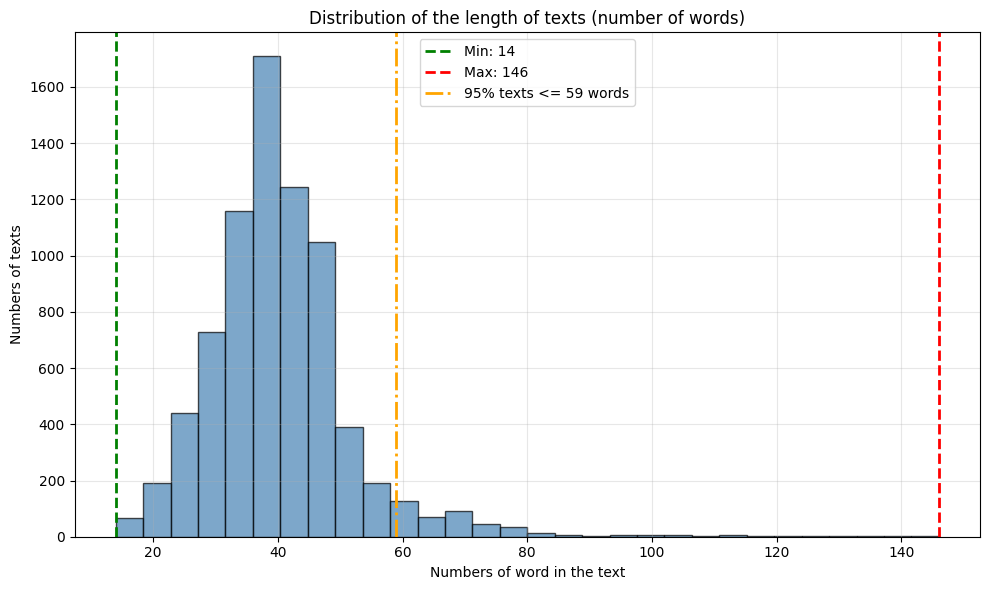

In [21]:
word_counts, min_words, max_words, recommended_len = analyze_text_lengths(dataset)
plot_word_count_histogram(word_counts)

In [22]:
MAX_LEN = recommended_len # Num of words we take from the beginning of each text
MAX_SHIFT = 21
TOTAL_WINDOW = MAX_LEN + MAX_SHIFT
D = len(wv['love']) # Size of the GloVe vector
D_pos = D + 1 # because the pos is a single num

def get_sentence_embedding(text, model, max_len, total_window, shift=0, add_position=False):
    d = model.vector_size
    words = tokenize(text)[:max_len]

    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
        else:
            vectors.append(np.zeros(d))

    matrix = np.zeros((total_window, d))
    matrix[shift : shift + len(vectors)] = vectors

    if add_position:
        pos_col = np.linspace(0, 1, total_window).reshape(-1, 1)
        matrix = np.hstack([matrix, pos_col])

    return matrix.flatten()

# Test:
sample_text = dataset['train'][0]['text']
sample_vector = get_sentence_embedding(sample_text, wv, MAX_LEN, TOTAL_WINDOW)
print(f"Vector shape for one news item : {sample_vector.shape}") # Expext (8000,)

Vector shape for one news item : (8000,)


## 1.2. Data preparation

In [9]:
import torch
import gc
from sklearn.model_selection import train_test_split

In [51]:
def prepare_experimental_data(dataset_subset, model, max_len, total_window, add_position=False):
    num_samples = len(dataset_subset)
    d_base = model.vector_size
    d_final = d_base + 1 if add_position else d_base

    # Сразу выделяем память (используем float32)
    X = np.empty((num_samples, total_window * d_final), dtype=np.float32)
    y = np.empty(num_samples, dtype=np.int64)

    for i, item in enumerate(tqdm(dataset_subset)):
        emb_matrix = get_sentence_embedding(item['text'], model, max_len, total_window, add_position=add_position)

        # Straighten into a single vector (Flatten)
        X[i] = emb_matrix
        y[i] = item['label']

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [11]:
train_size = 70000
val_size = 10000
test_size = len(dataset['test'])

In [12]:
full_data_subset = dataset['train'].shuffle(seed=42).select(range(train_size+val_size))
all_labels = full_data_subset['label']

train_idx, val_idx = train_test_split(
    range(len(full_data_subset)),
    test_size=val_size,
    random_state=42,
    stratify=all_labels
)

def get_subset(full_ds, indices):
    return full_ds.select(indices)

# 2. Model training

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import copy
import random

In [29]:
class MeanPoolingModel(nn.Module):
    def __init__(self, emb_dim, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim, hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, TOTAL_WINDOW, D)

        mask = (x.abs().sum(dim=2) > 0).float()
        sum_embeddings = x.sum(dim=1)
        word_count = mask.sum(dim=1, keepdim=True).clamp(min=1)
        x = sum_embeddings / word_count
        x = self.dropout(F.relu(self.bn(self.fc1(x))))

        return self.fc2(x)

In [15]:
class RobustFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.dropout(F.relu(self.bn(self.fc1(x))))
        return self.fc2(x)

In [16]:
hidden_size = 32
num_classes = 4

In [17]:
def train_model(model, train_tensors, val_tensors, epochs=10, batch_size=64, patience=3, lr=0.001, weight_decay=0.05):
    X_train, y_train = train_tensors
    X_val, y_val = val_tensors

    loader_train = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    loader_val = DataLoader(TensorDataset(X_val, y_val), batch_size=64)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.5)


    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_val_acc = 0
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # train
        model.train()
        running_loss, correct_train, total_train = 0, 0, 0

        for batch_X, batch_y in loader_train:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()

        epoch_train_loss = running_loss / len(loader_train)
        epoch_train_acc = 100 * correct_train / total_train

        # validation
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for batch_X, batch_y in loader_val:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()

        epoch_val_loss = running_val_loss / len(loader_val)
        epoch_val_acc = 100 * correct_val / total_val

        #scheduler.step(epoch_val_acc)

        # Recording history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        # Early stopping
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early Stopping! The model has not improved for {patience} epochs.")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"The training is completed. Loaded weights with the best Val Acc: {best_val_acc:.2f}%")

    return model, history

In [18]:
def plot_training_history(history, title_suffix=""):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Val Loss')
    plt.title(f'Loss Evolution {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot acc
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Val Acc')
    plt.title(f'Accuracy Evolution {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.show()

### Genarating data for Mean Pooling and STD Flatten

In [25]:
print("Generating Train STD...")
X_train_std, y_train = prepare_experimental_data(get_subset(full_data_subset, train_idx), wv, MAX_LEN, TOTAL_WINDOW, add_position=False)
print("Generating Val STD...")
X_val_std, y_val = prepare_experimental_data(get_subset(full_data_subset, val_idx), wv, MAX_LEN, TOTAL_WINDOW, add_position=False)

Generating Train STD...


100%|██████████| 70000/70000 [00:30<00:00, 2317.93it/s]


Generating Val STD...


100%|██████████| 10000/10000 [00:05<00:00, 1684.79it/s]


In [30]:
# Mean Pooling
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

print("Training Mean Pooling\n")
model_mean, history_mean = train_model(MeanPoolingModel(D, hidden_size, num_classes), (X_train_std, y_train), (X_val_std, y_val))

Training Mean Pooling

Epoch 01/10 | Train Acc: 86.08% | Val Acc: 88.90% | Val Loss: 0.3266
Epoch 02/10 | Train Acc: 87.96% | Val Acc: 88.75% | Val Loss: 0.3232
Epoch 03/10 | Train Acc: 88.19% | Val Acc: 88.71% | Val Loss: 0.3211
Epoch 04/10 | Train Acc: 88.46% | Val Acc: 89.39% | Val Loss: 0.3097
Epoch 05/10 | Train Acc: 88.45% | Val Acc: 89.30% | Val Loss: 0.3083
Epoch 06/10 | Train Acc: 88.55% | Val Acc: 89.45% | Val Loss: 0.3033
Epoch 07/10 | Train Acc: 88.63% | Val Acc: 89.30% | Val Loss: 0.3059
Epoch 08/10 | Train Acc: 88.67% | Val Acc: 89.36% | Val Loss: 0.3032
Epoch 09/10 | Train Acc: 88.66% | Val Acc: 89.56% | Val Loss: 0.2999
Epoch 10/10 | Train Acc: 88.75% | Val Acc: 89.73% | Val Loss: 0.2978
The training is completed. Loaded weights with the best Val Acc: 89.73%


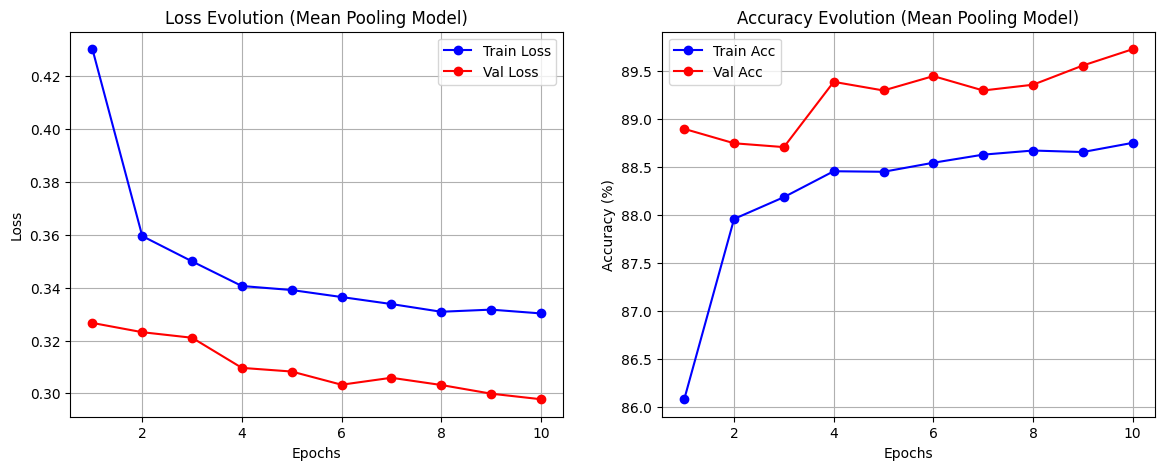

In [31]:
# Mean Pooling
plot_training_history(history_mean, "(Mean Pooling Model)")

In [32]:
# Standard Flatten
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

print("Training Standard Flatten\n")
std_shape = D * TOTAL_WINDOW
model_std, history_std = train_model(RobustFFNN(std_shape, hidden_size, num_classes), (X_train_std, y_train), (X_val_std, y_val))

Training Standard Flatten

Epoch 01/10 | Train Acc: 85.37% | Val Acc: 88.14% | Val Loss: 0.3359
Epoch 02/10 | Train Acc: 87.97% | Val Acc: 88.75% | Val Loss: 0.3237
Epoch 03/10 | Train Acc: 88.95% | Val Acc: 88.71% | Val Loss: 0.3221
Epoch 04/10 | Train Acc: 89.54% | Val Acc: 88.62% | Val Loss: 0.3266
Epoch 05/10 | Train Acc: 90.06% | Val Acc: 88.34% | Val Loss: 0.3336
Early Stopping! The model has not improved for 3 epochs.
The training is completed. Loaded weights with the best Val Acc: 88.75%


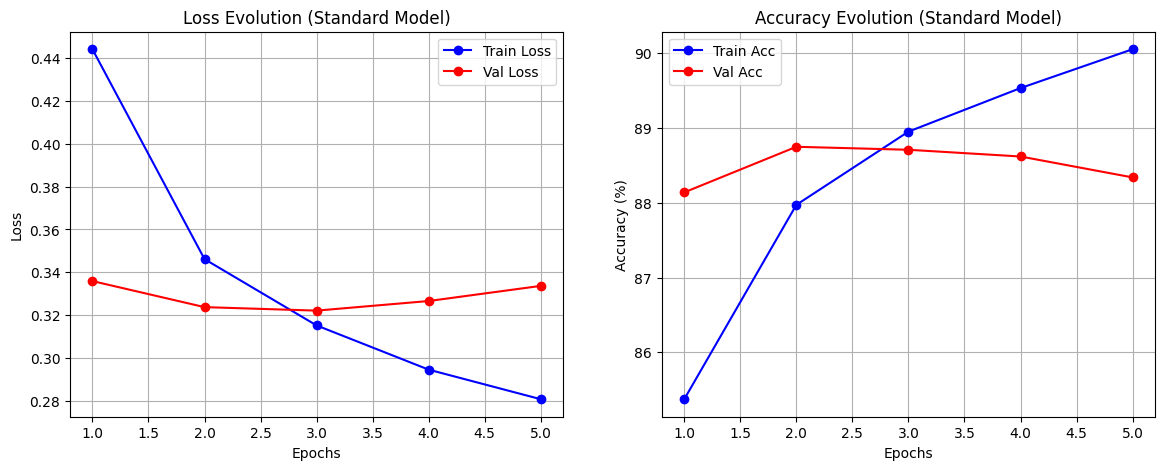

In [33]:
# Standard Flatten
plot_training_history(history_std, "(Standard Model)")

In [34]:
del X_train_std, X_val_std
gc.collect()

15243

### Generating data for POS-Aware

In [52]:
print("Generating Train POS...")
X_train_pos, _ = prepare_experimental_data(get_subset(full_data_subset, train_idx), wv, MAX_LEN, TOTAL_WINDOW, add_position=True)
print("Generating Val POS...")
X_val_pos, _ = prepare_experimental_data(get_subset(full_data_subset, val_idx), wv, MAX_LEN, TOTAL_WINDOW, add_position=True)

del full_data_subset
gc.collect()

Generating Train POS...


100%|██████████| 70000/70000 [00:27<00:00, 2580.93it/s]


Generating Val POS...


100%|██████████| 10000/10000 [00:05<00:00, 1954.96it/s]


1698

In [53]:
# Position-Aware Flatten
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

print("Training Position-Aware\n")
pos_shape = D_pos * TOTAL_WINDOW
model_pos, history_pos = train_model(RobustFFNN(pos_shape, hidden_size, num_classes), (X_train_pos, y_train), (X_val_pos, y_val))

Training Position-Aware

Epoch 01/10 | Train Acc: 85.34% | Val Acc: 88.63% | Val Loss: 0.3282
Epoch 02/10 | Train Acc: 87.93% | Val Acc: 88.72% | Val Loss: 0.3243
Epoch 03/10 | Train Acc: 88.73% | Val Acc: 88.72% | Val Loss: 0.3236
Epoch 04/10 | Train Acc: 89.34% | Val Acc: 88.37% | Val Loss: 0.3302
Epoch 05/10 | Train Acc: 90.04% | Val Acc: 88.44% | Val Loss: 0.3314
Early Stopping! The model has not improved for 3 epochs.
The training is completed. Loaded weights with the best Val Acc: 88.72%


Training Position-Aware



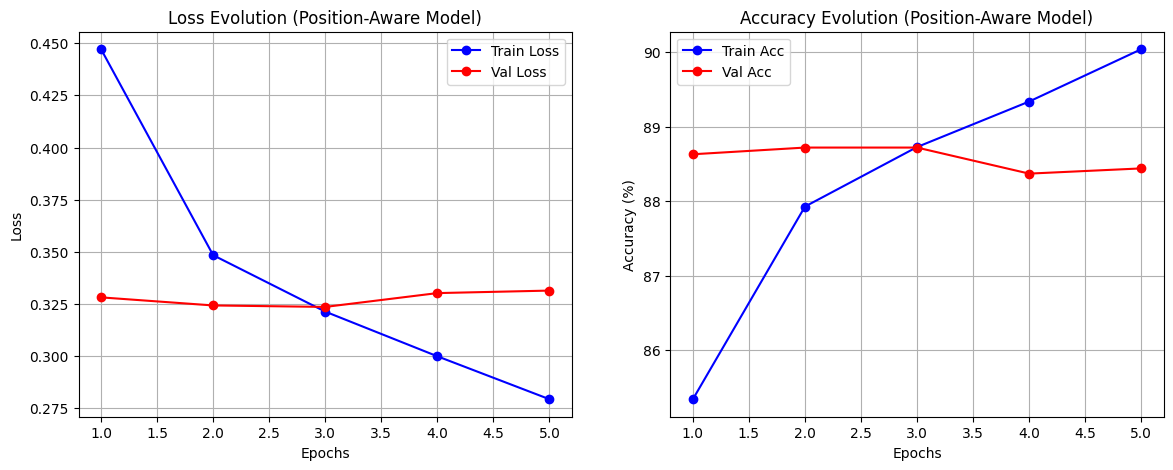

In [54]:
# Position-Aware Flatten
print("Training Position-Aware\n")
plot_training_history(history_pos, "(Position-Aware Model)")

In [55]:
del X_train_pos, X_val_pos, y_train, y_val
gc.collect()

7552

# 3. Conducting an experiment

In [56]:
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar

### Generating Test data

In [57]:
print("Generating Test...")
all_test_labels = dataset['test']['label']

if test_size < len(dataset['test']):
  _, final_test_indices = train_test_split(
      range(len(dataset['test'])),
      test_size=test_size,
      stratify=all_test_labels,
      random_state=42
  )

  X_test = dataset['test'].select(final_test_indices)
else:
  X_test = dataset['test']

y_test = torch.tensor(np.array(X_test['label']), dtype=torch.long)

Generating Test...


In [60]:
def create_shifted_data(dataset_subset, model, max_len, total_window, shift=5, add_position=False):
    if not (0 <= shift <= (total_window - max_len)):
        raise ValueError(f"Shift {shift} out of bounds.")

    d = model.vector_size + 1 if add_position else model.vector_size

    X_shifted = []
    for item in tqdm(dataset_subset):
        emb_matrix = get_sentence_embedding(item['text'], model, max_len, total_window,
                                            shift=shift, add_position=add_position)
        X_shifted.append(emb_matrix)

    return torch.tensor(np.array(X_shifted), dtype=torch.float32)

In [61]:
def evaluate_metrics(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs.data, 1)

        y_true = y_test.cpu().numpy()
        y_pred = predicted.cpu().numpy()

        acc = 100 * (y_pred == y_true).mean()
        f1 = 100 * f1_score(y_true, y_pred, average='macro')

    return acc, f1

In [62]:
results = {
    'mean': {'acc': [], 'f1': []},
    'std':  {'acc': [], 'f1': []},
    'pos':  {'acc': [], 'f1': []}
}

shifts = range(21)

print("Start Shift-test...")

for s in shifts:
    # Preparation data for models without clear pos (Mean и Std)
    X_s_std = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=s, add_position=False)
    # Preparation data for model with clear pos
    X_s_pos = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=s, add_position=True)

    # Mean pooling
    acc_m, f1_m = evaluate_metrics(model_mean, X_s_std, y_test)
    results['mean']['acc'].append(acc_m); results['mean']['f1'].append(f1_m)

    # Std flatten
    acc_s, f1_s = evaluate_metrics(model_std, X_s_std, y_test)
    results['std']['acc'].append(acc_s); results['std']['f1'].append(f1_s)

    # Pos-Aware Flatten
    acc_p, f1_p = evaluate_metrics(model_pos, X_s_pos, y_test)
    results['pos']['acc'].append(acc_p); results['pos']['f1'].append(f1_p)

    print(f"Shift {s}: Mean Acc={acc_m:.1f}%, Std Acc={acc_s:.1f}%, Pos Acc={acc_p:.1f}%")

Start Shift-test...


100%|██████████| 7600/7600 [00:02<00:00, 2962.29it/s]


Shift 0: Mean Acc=89.4%, Std Acc=88.1%, Pos Acc=88.5%


100%|██████████| 7600/7600 [00:04<00:00, 1787.50it/s]


Shift 1: Mean Acc=89.4%, Std Acc=87.7%, Pos Acc=88.3%


...

Shift 18: Mean Acc=89.4%, Std Acc=80.7%, Pos Acc=81.7%


100%|██████████| 7600/7600 [00:02<00:00, 3304.02it/s]


Shift 19: Mean Acc=89.4%, Std Acc=79.6%, Pos Acc=80.4%


100%|██████████| 7600/7600 [00:02<00:00, 3303.30it/s]


Shift 20: Mean Acc=89.4%, Std Acc=78.2%, Pos Acc=79.7%


In [63]:
def plot_shift_results(results, shifts):
    plt.figure(figsize=(15, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(shifts, results['mean']['acc'], 'g-o', label='Mean Pooling (Baseline)')
    plt.plot(shifts, results['std']['acc'], 'b-s', label='Std Flatten (Implicit)')
    plt.plot(shifts, results['pos']['acc'], 'r-^', label='Pos-Aware (Hybrid)')
    plt.title('Accuracy Degradation vs Shift Size')
    plt.xlabel('Shift Size (tokens)')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # Plot macto F1-Score
    plt.subplot(1, 2, 2)
    plt.plot(shifts, results['mean']['f1'], 'g-o', label='Mean Pooling')
    plt.plot(shifts, results['std']['f1'], 'b-s', label='Std Flatten')
    plt.plot(shifts, results['pos']['f1'], 'r-^', label='Pos-Aware')
    plt.title('Macro F1-Score Degradation vs Shift Size')
    plt.xlabel('Shift Size (tokens)')
    plt.ylabel('F1-Score (%)')
    plt.legend()
    plt.grid(True)

    plt.show()

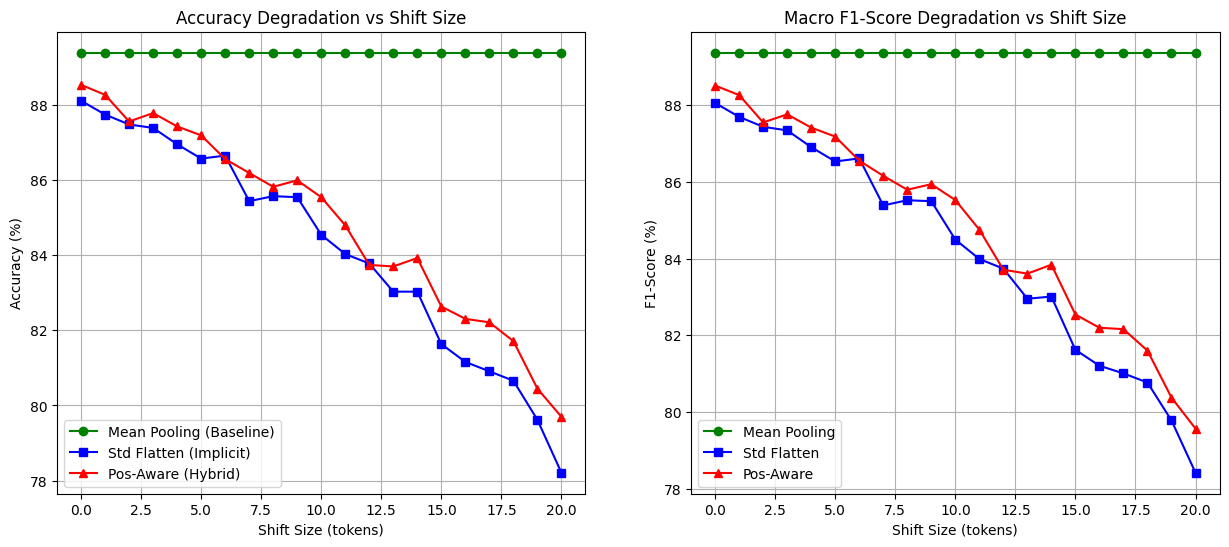

In [64]:
plot_shift_results(results, shifts)

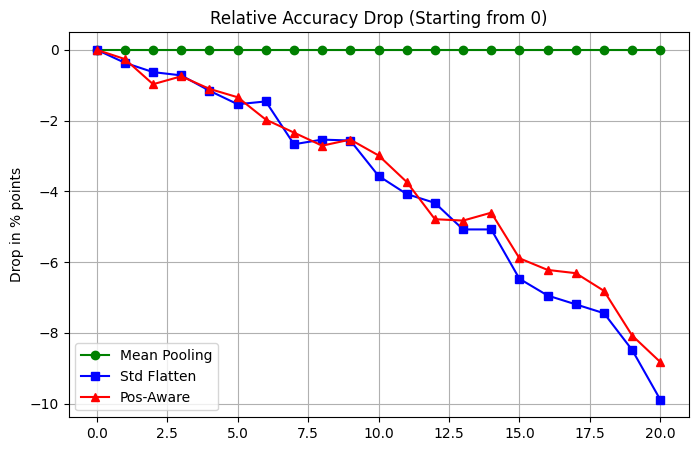

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(shifts, [results['mean']['acc'][i] - results['mean']['acc'][0] for i in range(len(shifts))], 'g-o', label='Mean Pooling')
plt.plot(shifts, [results['std']['acc'][i] - results['std']['acc'][0] for i in range(len(shifts))], 'b-s', label='Std Flatten')
plt.plot(shifts, [results['pos']['acc'][i] - results['pos']['acc'][0] for i in range(len(shifts))], 'r-^', label='Pos-Aware')
plt.title('Relative Accuracy Drop (Starting from 0)')
plt.ylabel('Drop in % points')
plt.grid(True)
plt.legend()
#plt.savefig('images/relative_accur_drop.png', dpi=300, bbox_inches='tight') # Сохранение
plt.show()

**Key Observations:**

- **Mean Pooling (Baseline):** Demonstrates absolute stability (0.00% drop). Because the model ignores word order, the semantic "word cloud" remains mathematically identical regardless of the shift, ensuring perfect invariance.

- **Flatten Architectures:** Both models suffer from significant accuracy loss (8–10%), confirming that any dependency on fixed coordinates makes the representations vulnerable to displacement.

  - **POS vs. STD:** Contrary to initial expectations, the Position-Aware (POS) model is more robust than the standard model (STD). This indicates that explicit positional indices provide a more stable "coordinate system," helping the model recognize shifted words better than purely implicit learning.

## 3.1 Stability Metrics & Heatmaps

In [66]:
def get_summary_table(results, shifts):
    summary_data = []

    for model_name, metrics in results.items():
        acc = metrics['acc']

        slope, _ = np.polyfit(shifts, acc, 1)
        volatility = np.std(acc)
        max_drop = acc[0] - acc[-1]
        total_loss = sum([acc[0] - a for a in acc])

        summary_data.append({
            "Model Architecture": model_name.upper(),
            "Slope (Sensitivity)": f"{slope:.3f}",
            "Volatility (Std)": f"{volatility:.3f}",
            "Max Drop (%)": f"{max_drop:.2f}%",
            "Total Loss Area": f"{total_loss:.2f}"
        })

    df = pd.DataFrame(summary_data)
    return df

summary_df = get_summary_table(results, shifts)
print("\nStability analysis table")
display(summary_df)


Stability analysis table


,Model Architecture,Slope (Sensitivity),Volatility (Std),Max Drop (%),Total Loss Area
0,MEAN,-0.000,0.000,0.00%,0.00
1,STD,-0.465,2.863,9.89%,82.24
2,POS,-0.417,2.564,8.83%,77.11


The Slope for the POS model is approximately 10% shallower than that of the STD model (-0.417 vs -0.465). This suggests that explicit positional features provide a more robust coordinate system compared to implicit weight geometry, which exhibits the highest sensitivity to contextual displacement.

In [67]:
def plot_comparative_confusion_matrices(model_mean, model_pos, X_test_std, X_test_pos, y_true_tensor):
    class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

    model_mean.eval()
    model_pos.eval()

    with torch.no_grad():
        # Mean Pooling (with shift)
        out_mean = model_mean(X_test_std)
        preds_mean = torch.max(out_mean, 1)[1].cpu().numpy()

        # Pos-Aware (with shift)
        out_pos = model_pos(X_test_pos)
        preds_pos = torch.max(out_pos, 1)[1].cpu().numpy()

    y_true = y_true_tensor.cpu().numpy()

    cm_mean = confusion_matrix(y_true, preds_mean, normalize='true')
    cm_pos = confusion_matrix(y_true, preds_pos, normalize='true')

    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_mean, annot=True, fmt='.2f', cmap='Greens', ax=axes1[0],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes1[0].set_title('Mean Pooling (Baseline)\nStable at Shift 10', fontsize=14)

    sns.heatmap(cm_pos, annot=True, fmt='.2f', cmap='Oranges', ax=axes1[1],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes1[1].set_title('Pos-Aware (Hybrid)\nFragile at Shift 10', fontsize=14)

    for ax in axes1:
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.show()

    # Difference matrix
    diff_cm = cm_pos - cm_mean

    plt.figure(figsize=(9, 7))
    sns.heatmap(diff_cm, annot=True, fmt='.2f', cmap='RdBu', center=0,
                xticklabels=class_names, yticklabels=class_names)

    plt.title('DIFFERENCE MATRIX (Pos-Aware minus Mean Pooling)\nBlue: POS is higher | Red: MEAN is higher', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

In [73]:
X_test_shifted_std = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=10, add_position=False)
X_test_shifted_pos = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=s, add_position=True)

100%|██████████| 7600/7600 [00:02<00:00, 3291.05it/s]


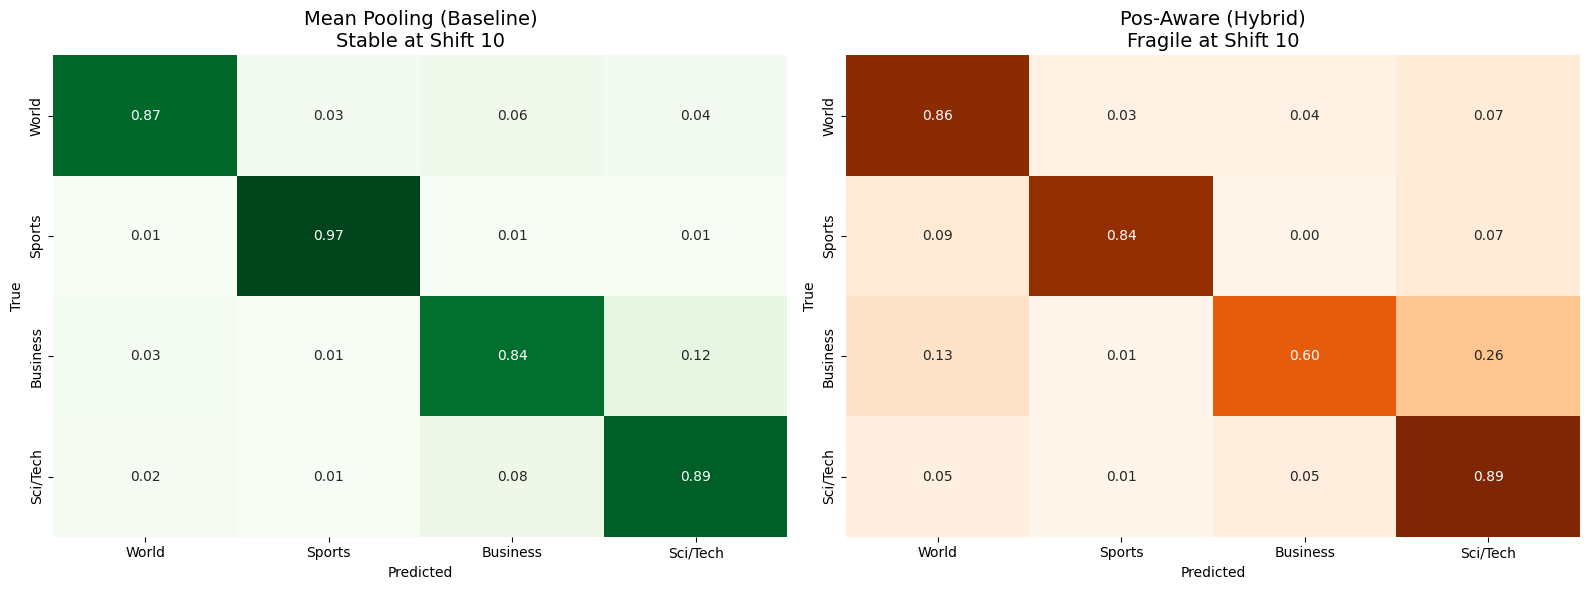

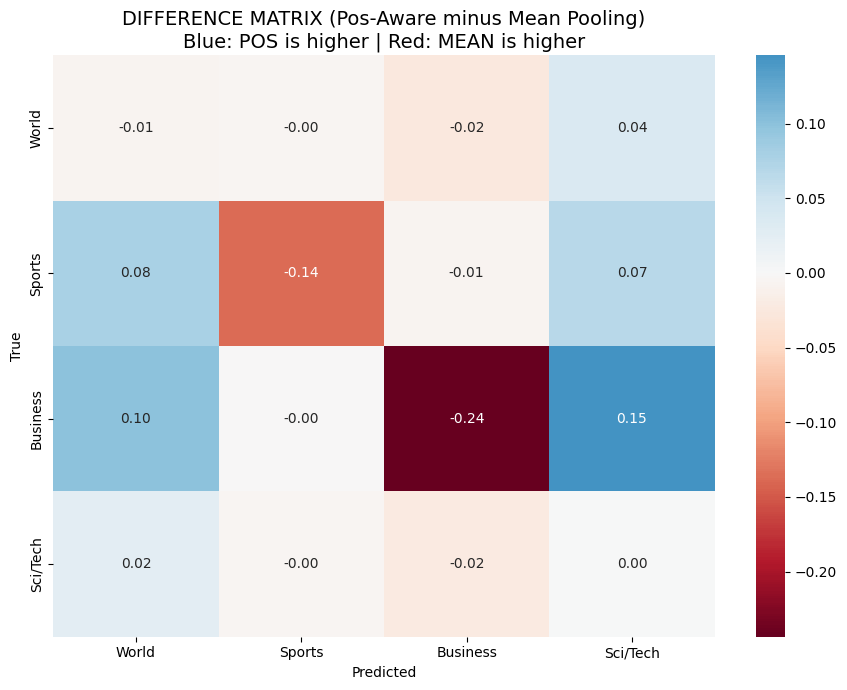

In [74]:
plot_comparative_confusion_matrices(model_mean, model_pos, X_test_shifted_std, X_test_shifted_pos, y_test)

- **Semantic Drift:** The POS model's accuracy in the **Business** category drops by **10%** compared to the baseline.
- **Class Confusion:** Under shift, the positional model primarily confuses *Business* with *World* and *Sci/Tech* topics.
- **Invariance:** Mean Pooling maintains a clean diagonal, while POS shows "red zones" of accuracy loss across all classes.

## 3.2 Hypothesis Testing (McNemar’s)

In [69]:
def run_mcnemar_test(y_true, pred_std, pred_pos):
    correct_std = (pred_std == y_true)
    correct_pos = (pred_pos == y_true)

    # 2x2 matrix
    # 1. STD Correct, POS Incorrect (AB)
    ab = int((correct_std & ~correct_pos).sum())

    # 2. STD Incorrect, POS Correct (BA)
    ba = int((~correct_std & correct_pos).sum())

    table = [[int((correct_std & correct_pos).sum()), ab],
             [ba, int((~correct_std & ~correct_pos).sum())]]

    # If discordant pairs are small, exact McNemar is better
    if ab + ba < 25:
        result = mcnemar(table, exact=True)
        method_used = "exact"
    else:
        result = mcnemar(table, exact=False, correction=True)
        method_used = "chi2_with_correction"

    return result.statistic, result.pvalue, ab, ba, table, method_used

In [70]:
shifts_to_test = [5, 10, 20]

model_std.eval()
model_pos.eval()

y_true = y_test.cpu().numpy()

mcnemar_results = {}

for s in shifts_to_test:
    # Preparation data for Standard model
    X_s_std = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=s, add_position=False)

    # Preparation data for Position-Aware model
    X_s_pos = create_shifted_data(X_test, wv, MAX_LEN, TOTAL_WINDOW,
                                  shift=s, add_position=True)

    with torch.no_grad():
        p_std = torch.max(model_std(X_s_std), 1)[1].cpu().numpy()
        p_pos = torch.max(model_pos(X_s_pos), 1)[1].cpu().numpy()

    stat, p_val, ab, ba, table, method_used = run_mcnemar_test(y_true, p_std, p_pos)

    mcnemar_results[s] = {
        'statistic': stat,
        'p_value': p_val,
        'ab': ab,
        'ba': ba,
        'table': table,
        'method': method_used
    }

    print(
        f"Shift {s}: "
        f"p-value={p_val:.6f} | "
        f"method={method_used} | "
        f"STD right / POS wrong={ab} | "
        f"POS right / STD wrong={ba}"
    )


100%|██████████| 7600/7600 [00:02<00:00, 3284.73it/s]


Shift 5: p-value=0.017229 | method=chi2_with_correction | STD right / POS wrong=163 | POS right / STD wrong=210


100%|██████████| 7600/7600 [00:02<00:00, 3313.00it/s]


Shift 10: p-value=0.001051 | method=chi2_with_correction | STD right / POS wrong=224 | POS right / STD wrong=300


100%|██████████| 7600/7600 [00:02<00:00, 3248.14it/s]


Shift 20: p-value=0.000115 | method=chi2_with_correction | STD right / POS wrong=365 | POS right / STD wrong=478


In [71]:
def display_mcnemar_table(table, shift_val):
    # matrix 2x2
    # table[0][0] - both are right
    # table[0][1] - STD right, POS wrong
    # table[1][0] - STD wrong, POS right
    # table[1][1] - both are wrong

    df_table = pd.DataFrame(
        table,
        index=['STD Correct', 'STD Incorrect'],
        columns=['POS Correct', 'POS Incorrect']
    )

    print(f"\nContingency Table for McNemar's Test (Shift {shift_val})")
    return df_table

In [72]:
for s in shifts_to_test:
    table_data = mcnemar_results[s]['table']
    df_result = display_mcnemar_table(table_data, s)

    display(df_result)
    print()


Contingency Table for McNemar's Test (Shift 5)


,POS Correct,POS Incorrect
STD Correct,6416,163
STD Incorrect,210,811




Contingency Table for McNemar's Test (Shift 10)


,POS Correct,POS Incorrect
STD Correct,6201,224
STD Incorrect,300,875




Contingency Table for McNemar's Test (Shift 20)


,POS Correct,POS Incorrect
STD Correct,5579,365
STD Incorrect,478,1178


- **Shift 5 to 20:** All tests yielded **p-value < 0.05**, confirming that the performance gap between STD and POS is statistically significant.
- **Erosion of Advantage:** The gap between POS-correct/STD-wrong and STD-correct/POS-wrong narrows as the shift increases, proving that the positional advantage is rapidly eroded by spatial noise.